In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path
from provided_code.utils import load_file
import pandas as pd

/Users/caiogould/CS129project/open-kbp/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.  (This may have returned Python scalars in past versions.
  if not hasattr(np, "object"):


In [8]:
# ---- choose patient once ----
pt_id = 206  # <-- change this number only

base = Path("/Users/caiogould/CS129project/open-kbp")
true_dose_dict = load_file(base / f"provided-data/validation-pats/pt_{pt_id}/dose.csv")

#pred_dose_dict = load_file(base / f"results/2convsperlevel_mse_noavgpool_filtersize3_200epochs/validation-predictions/pt_{pt_id}.csv")
#pred_dose_dict = load_file(base / f"results/2convsperlevel_mse_noavgpool_filtersize3_50epochs/validation-predictions/pt_{pt_id}.csv")
pred_dose_dict = load_file(base / f"results/2convsperlevel_v8_8filters_200epochs/validation-predictions/pt_{pt_id}.csv")
ct_dict = load_file(base / f"provided-data/validation-pats/pt_{pt_id}/ct.csv")
brainstem_dict = load_file(base / f"provided-data/validation-pats/pt_{pt_id}/Brainstem.csv")
structure_dict = load_file(base / f"provided-data/validation-pats/pt_{pt_id}/PTV56.csv")
structure_dict2 = load_file(base / f"provided-data/validation-pats/pt_{pt_id}/PTV63.csv")
structure_dict3 = load_file(base / f"provided-data/validation-pats/pt_{pt_id}/PTV70.csv")

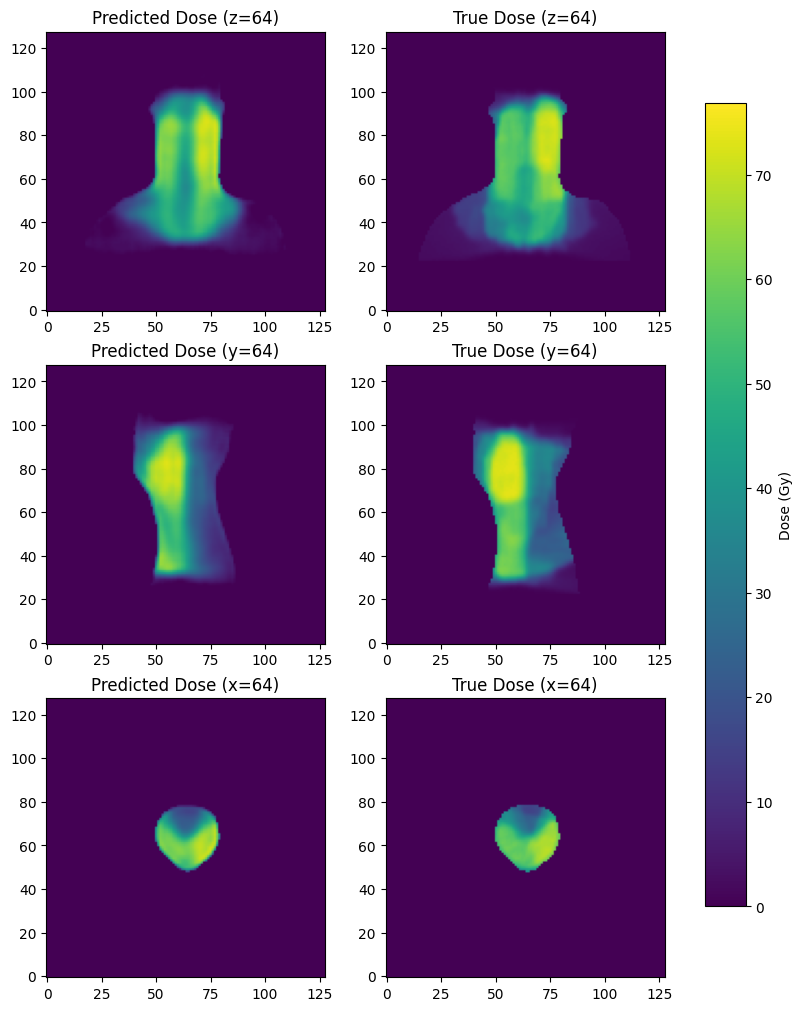

In [9]:
def dense_from_dict(d):
    dose = np.zeros((128, 128, 128), dtype=np.float32)
    np.put(dose, d["indices"], d["data"])
    return dose

# ---- reconstruct ----
pred_dose = dense_from_dict(pred_dose_dict)
true_dose = dense_from_dict(true_dose_dict)

# ---- center slices ----
z = pred_dose.shape[0] // 2
y = pred_dose.shape[1] // 2
x = pred_dose.shape[2] // 2

pred_slices = [
    np.rot90(pred_dose[z, :, :]),
    np.rot90(pred_dose[:, y, :]),
    pred_dose[:, :, x],
]

true_slices = [
    np.rot90(true_dose[z, :, :]),
    np.rot90(true_dose[:, y, :]),
    true_dose[:, :, x],
]

slice_names = [f"z={z}", f"y={y}", f"x={x}"]

# ---- shared color scale ----
vmin = min(pred_dose.min(), true_dose.min())
vmax = max(pred_dose.max(), true_dose.max())

# ---- plot ----
fig, axes = plt.subplots(3, 2, figsize=(8, 10), constrained_layout=True)

for i in range(3):
    im0 = axes[i, 0].imshow(pred_slices[i], origin="lower", vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"Predicted Dose ({slice_names[i]})")

    im1 = axes[i, 1].imshow(true_slices[i], origin="lower", vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"True Dose ({slice_names[i]})")

# single shared colorbar
cbar = fig.colorbar(im1, ax=axes, shrink=0.85)
cbar.set_label("Dose (Gy)")

plt.show()

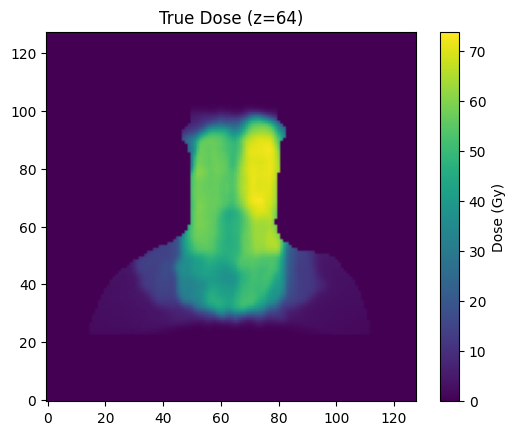

In [51]:
def dense_from_dict(d):
    dose = np.zeros((128, 128, 128), dtype=np.float32)
    np.put(dose, d["indices"], d["data"])
    return dose

# ---- reconstruct ----
true_dose = dense_from_dict(true_dose_dict)

# ---- center z slice ----
z = true_dose.shape[0] // 2
true_slice = np.rot90(true_dose[z, :, :])

# ---- color scale ----
vmin = true_dose.min()
vmax = true_dose.max()

# ---- plot ----
im = plt.imshow(true_slice, origin="lower", vmin=vmin, vmax=vmax)
plt.title(f"True Dose (z={z})")
plt.colorbar(im, label="Dose (Gy)")
plt.show()

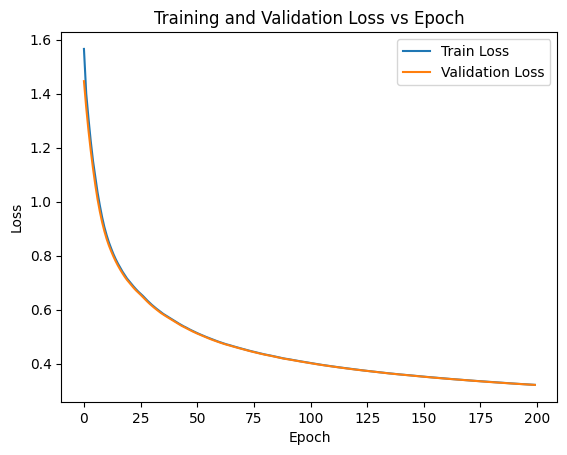

In [92]:
# Path to your CSV file
csv_path = "/Users/caiogould/CS129project/open-kbp/results/2convsperlevel_v8_8filters_200epochs/loss_history.csv"   # change this

# Read data
df = pd.read_csv(csv_path)

# Plot
plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.show()

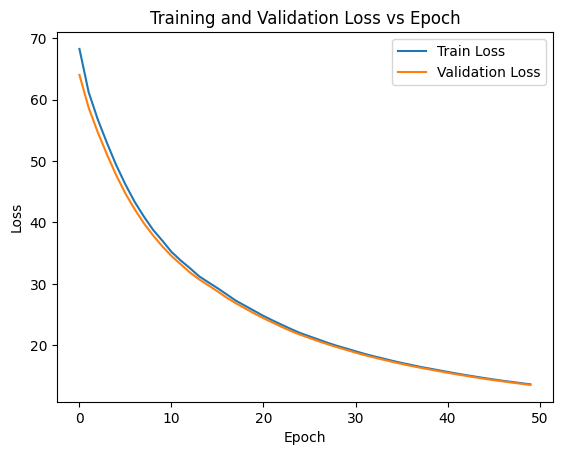

In [143]:
# Path to your CSV file
csv_path = "/Users/caiogould/CS129project/open-kbp/results/2convsperlevel_mse_noavgpool_filtersize3_50epochs/loss_history.csv"   # change this

# Read data
df = pd.read_csv(csv_path)

# Plot
plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.show()

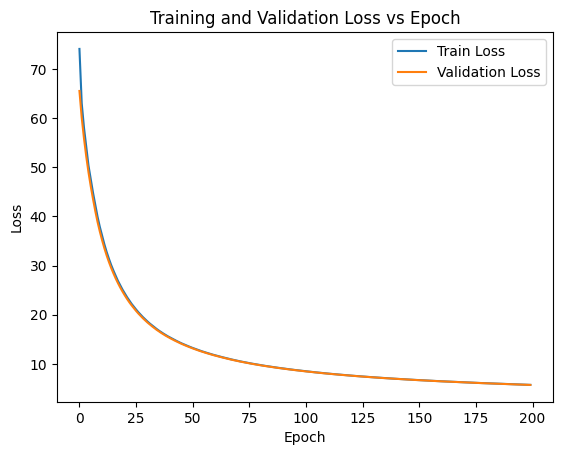

In [148]:
# Path to your CSV file
csv_path = "/Users/caiogould/CS129project/open-kbp/results/2convsperlevel_mse_noavgpool_filtersize3_200epochs/loss_history.csv"   # change this

# Read data
df = pd.read_csv(csv_path)

# Plot
plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.show()

nonzero voxels: 159541
index range: 647053 to 1497961
dose min/max (nonzero): 1.0 4075.0
dense min/max: 0.0 4075.0


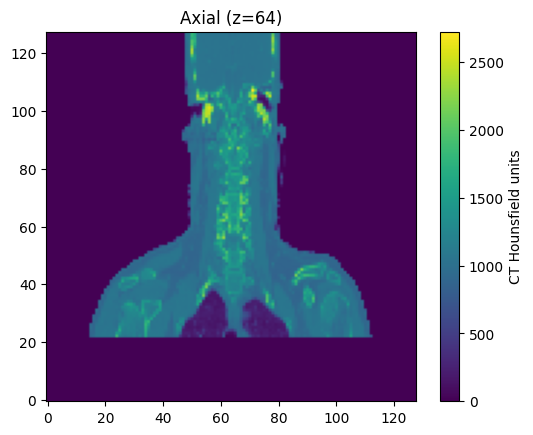

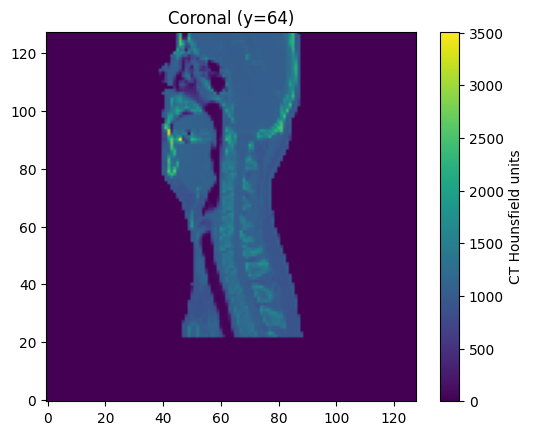

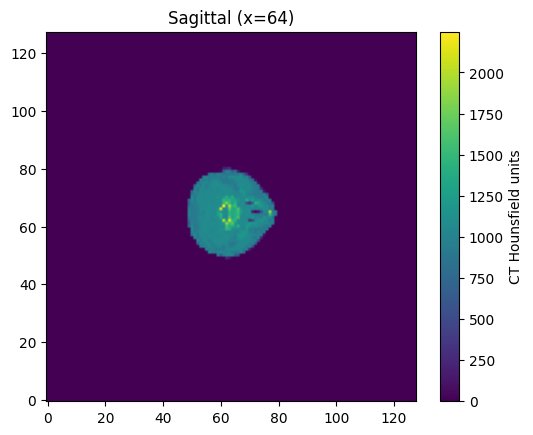

'\n# ---- plot 3 orthogonal center slices ----\nz = dose.shape[0] // 2\ny = dose.shape[1] // 2\nx = dose.shape[2] // 2\n\nplt.figure()\nplt.imshow(dose[z, :, :], origin="lower")\nplt.title(f"CT: z={z}")\nplt.colorbar(label="CT Hounsfield units")\nplt.show()\n\nplt.figure()\nplt.imshow(dose[:, y, :], origin="lower")\nplt.title(f"CT: y={y}")\nplt.colorbar(label="CT Hounsfield units")\nplt.show()\n\nplt.figure()\nplt.imshow(dose[:, :, x], origin="lower")\nplt.title(f"CT: x={x}")\nplt.colorbar(label="CT Hounsfield units")\nplt.show()\n'

In [ ]:
# ---- reconstruct dense 3D dose ----
indices = ct_dict["indices"]
values  = ct_dict["data"]

dose = np.zeros((128, 128, 128), dtype=np.float32)
np.put(dose, indices, values)

print("nonzero voxels:", len(indices))
print("index range:", int(indices.min()), "to", int(indices.max()))
print("dose min/max (nonzero):", float(values.min()), float(values.max()))
print("dense min/max:", float(dose.min()), float(dose.max()))

# ---- plot 3 orthogonal center slices ----
z = dose.shape[0] // 2
y = dose.shape[1] // 2
x = dose.shape[2] // 2

# Axial (z slice) – unchanged
plt.figure()
plt.imshow(np.rot90(dose[z, :, :]), origin="lower")
plt.title(f"Axial (z={z})")
plt.colorbar(label="CT Hounsfield units")
plt.show()

# Coronal (y slice) – rotate right
plt.figure()
plt.imshow(np.rot90(dose[:, y, :]), origin="lower")
plt.title(f"Coronal (y={y})")
plt.colorbar(label="CT Hounsfield units")
plt.show()

# Sagittal (x slice) – rotate right
plt.figure()
plt.imshow(np.rot90(dose[:, :, x], k=-1), origin="lower")
plt.title(f"Sagittal (x={x})")
plt.colorbar(label="CT Hounsfield units")
plt.show()

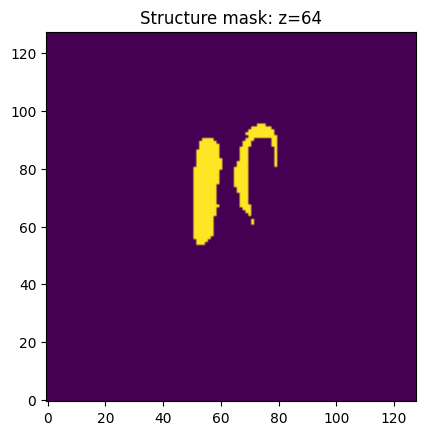

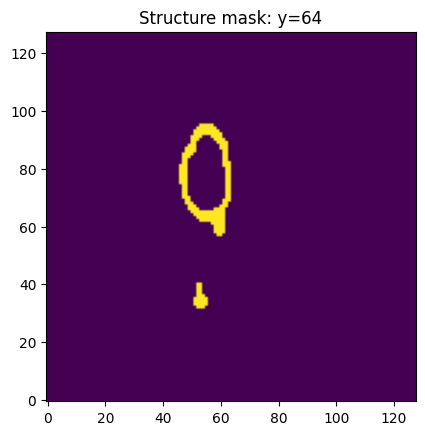

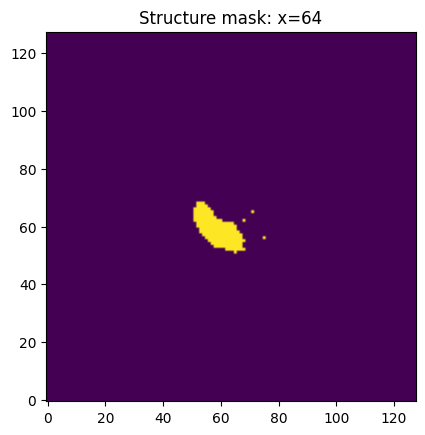

In [19]:
if isinstance(structure_dict, dict):
    structure_indices = structure_dict.get("indices", None)
    if structure_indices is None:
        # sometimes it might be stored under a different key
        raise ValueError(f"Unexpected dict keys: {structure_dict.keys()}")
else:
    structure_indices = structure_dict

structure_indices = np.asarray(structure_indices, dtype=np.int64)

structure_mask = np.zeros((128, 128, 128), dtype=np.uint8)
np.put(structure_mask, structure_indices, 1)

# ---- plot 3 orthogonal center slices ----
z = structure_mask.shape[0] // 2
y = structure_mask.shape[1] // 2
x = structure_mask.shape[2] // 2

plt.figure()
plt.imshow(np.rot90(structure_mask[z, :, :]), origin="lower")
plt.title(f"Structure mask: z={z}")
plt.show()

plt.figure()
plt.imshow(np.rot90(structure_mask[:, y, :]), origin="lower")
plt.title(f"Structure mask: y={y}")
plt.show()

plt.figure()
plt.imshow(structure_mask[:, :, x], origin="lower")
plt.title(f"Structure mask: x={x}")
plt.show()

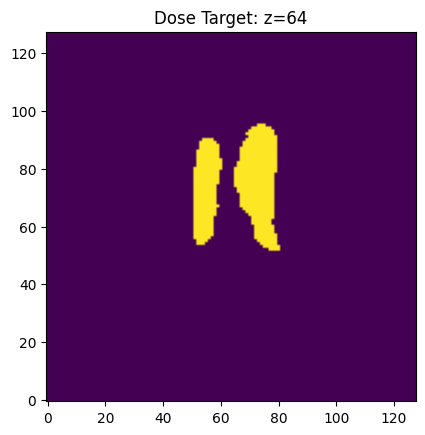

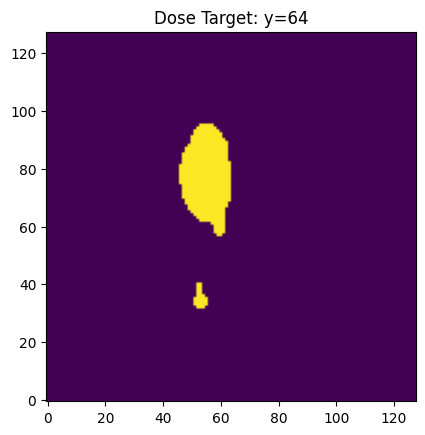

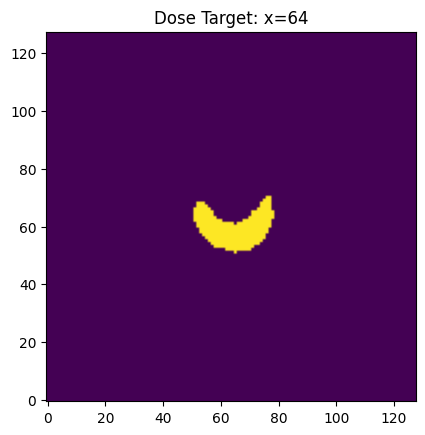

In [ ]:
def get_indices(structure_like):
    if isinstance(structure_like, dict):
        idx = structure_like.get("indices", None)
        if idx is None:
            raise ValueError(f"Unexpected dict keys: {structure_like.keys()}")
        return idx
    return structure_like

# ---- collect + combine indices from 3 structures ----
idx1 = np.asarray(get_indices(structure_dict),  dtype=np.int64)
idx2 = np.asarray(get_indices(structure_dict2), dtype=np.int64)
idx3 = np.asarray(get_indices(structure_dict3), dtype=np.int64)

combined_indices = np.concatenate([idx1, idx2, idx3])
combined_indices = np.unique(combined_indices)  # optional but nice

# ---- build combined mask (union) ----
structure_mask = np.zeros((128, 128, 128), dtype=np.uint8)
np.put(structure_mask, combined_indices, 1)

# ---- plot 3 orthogonal center slices ----
z = structure_mask.shape[0] // 2
y = structure_mask.shape[1] // 2
x = structure_mask.shape[2] // 2

plt.figure()
plt.imshow(np.rot90(structure_mask[z, :, :]), origin="lower")
plt.title(f"Dose Target: z={z}")
plt.show()

plt.figure()
plt.imshow(np.rot90(structure_mask[:, y, :]), origin="lower")
plt.title(f"Dose Target: y={y}")
plt.show()

plt.figure()
plt.imshow(structure_mask[:, :, x], origin="lower")
plt.title(f"Dose Target: x={x}")
plt.show()

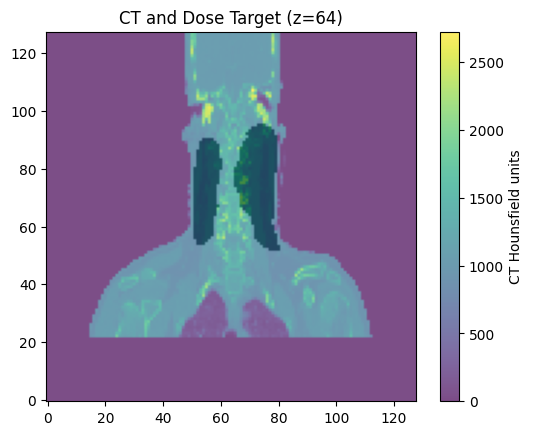

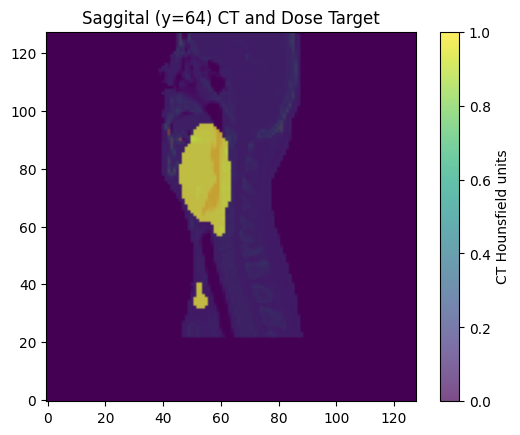

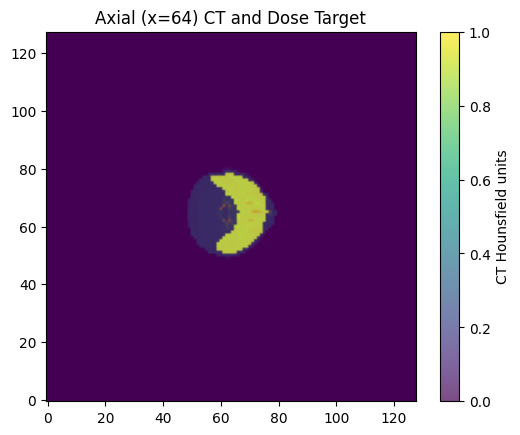

In [46]:
# Assumes you already built `structure_mask` (union of the 3 structures)
# and `dose` is the dense CT volume (your variable name is `dose`)

z = dose.shape[0] // 2
y = dose.shape[1] // 2
x = dose.shape[2] // 2

alpha = 0.7  # overlay transparency

# --- Coronal (z slice) ---
plt.figure()
ct_ax = np.rot90(dose[z, :, :])                 # match your CT rotation
m_ax  = np.rot90(structure_mask[z, :, :])       # rotate mask the same way
plt.imshow(m_ax, origin="lower",cmap='Grays')
plt.imshow(ct_ax, origin="lower",alpha=alpha)
plt.title(f"CT and Dose Target (z={z})")
plt.colorbar(label="CT Hounsfield units")
plt.show()

# --- Saggital (y slice) ---
plt.figure()
ct_co = np.rot90(dose[:, y, :])                 # match your CT rotation
m_co  = np.rot90(structure_mask[:, y, :])       # rotate mask the same way
plt.imshow(ct_co, origin="lower")
plt.imshow(m_co, origin="lower", alpha=alpha)
plt.title(f"Saggital (y={y}) CT and Dose Target")
plt.colorbar(label="CT Hounsfield units")
plt.show()

# --- Axial (x slice) ---
plt.figure()
ct_sa = np.rot90(dose[:, :, x], k=-1)           # match your CT rotation
m_sa  = np.rot90(structure_mask[:, :, x], k=-1) # rotate mask the same way
plt.imshow(ct_sa, origin="lower")
plt.imshow(m_sa, origin="lower", alpha=alpha)
plt.title(f"Axial (x={x}) CT and Dose Target")
plt.colorbar(label="CT Hounsfield units")
plt.show()

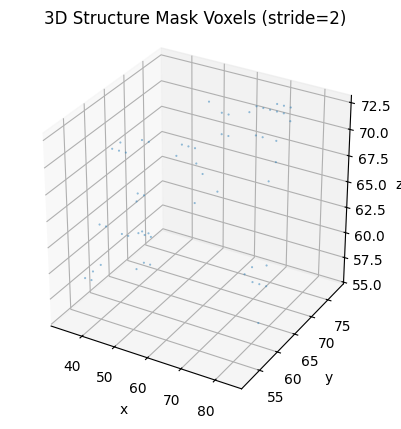

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# structure_mask: (128,128,128) with 0/1 values

stride = 2  # 1 = all points (can be heavy). Try 2–4.

m = structure_mask[::stride, ::stride, ::stride]
zz, yy, xx = np.nonzero(m)  # coords in downsampled grid

# scale back to original coordinates
zz = zz * stride
yy = yy * stride
xx = xx * stride

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(xx, yy, zz, s=1, alpha=0.5, marker='.')
ax.set_title(f"3D Structure Mask Voxels (stride={stride})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

# Make aspect ratio closer to cubic
ax.set_box_aspect((structure_mask.shape[2], structure_mask.shape[1], structure_mask.shape[0]))

plt.show()

nonzero voxels: 33721
index range: 630727 to 1467316
dose min/max (nonzero): 3.884898251271807e-05 76.71316528320312
dense min/max: 0.0 76.71316528320312


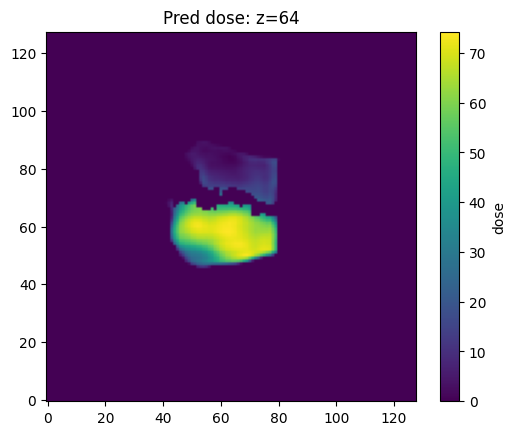

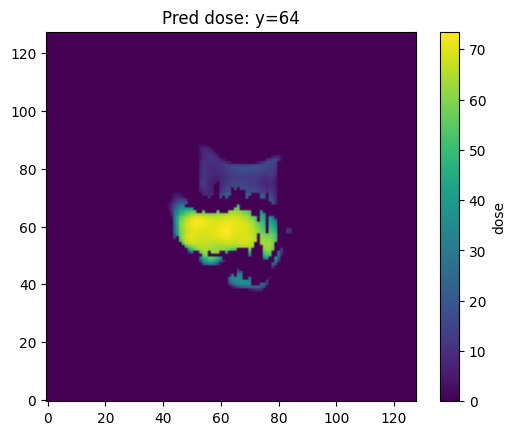

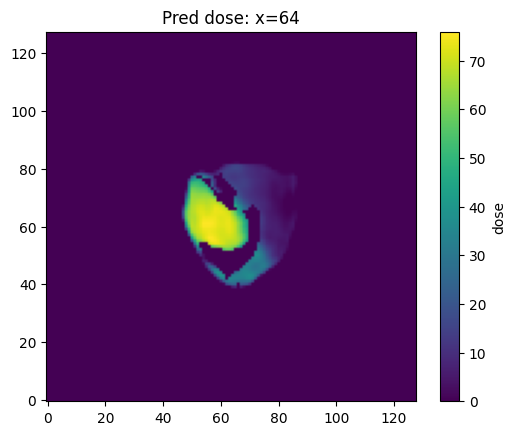

In [39]:
# ---- reconstruct dense 3D dose ----
indices = pred_dose_dict["indices"]
values  = pred_dose_dict["data"]

dose = np.zeros((128, 128, 128), dtype=np.float32)
np.put(dose, indices, values)

print("nonzero voxels:", len(indices))
print("index range:", int(indices.min()), "to", int(indices.max()))
print("dose min/max (nonzero):", float(values.min()), float(values.max()))
print("dense min/max:", float(dose.min()), float(dose.max()))

# ---- plot 3 orthogonal center slices ----
z = dose.shape[0] // 2
y = dose.shape[1] // 2
x = dose.shape[2] // 2

plt.figure()
plt.imshow(dose[z, :, :], origin="lower")
plt.title(f"Pred dose: z={z}")
plt.colorbar(label="dose")
plt.show()

plt.figure()
plt.imshow(dose[:, y, :], origin="lower")
plt.title(f"Pred dose: y={y}")
plt.colorbar(label="dose")
plt.show()

plt.figure()
plt.imshow(dose[:, :, x], origin="lower")
plt.title(f"Pred dose: x={x}")
plt.colorbar(label="dose")
plt.show()

nonzero voxels: 39675
index range: 614452 to 1467956
dose min/max (nonzero): 0.0 77.625
dense min/max: 0.0 77.625


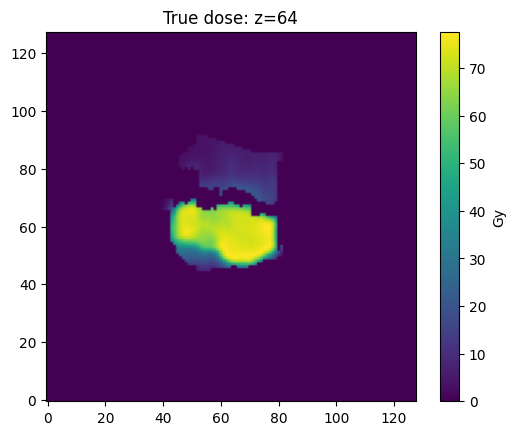

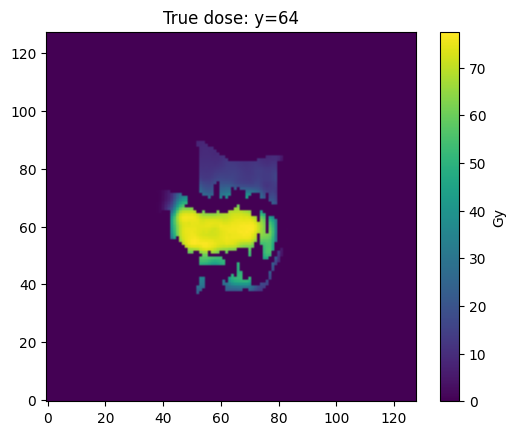

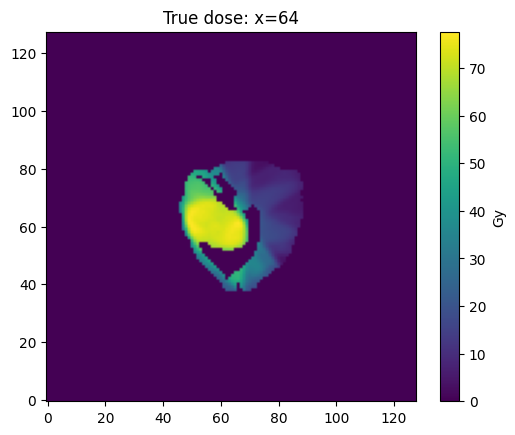

In [40]:
# ---- reconstruct dense 3D dose ----
indices = true_dose_dict["indices"]
values  = true_dose_dict["data"]

dose = np.zeros((128, 128, 128), dtype=np.float32)
np.put(dose, indices, values)

print("nonzero voxels:", len(indices))
print("index range:", int(indices.min()), "to", int(indices.max()))
print("dose min/max (nonzero):", float(values.min()), float(values.max()))
print("dense min/max:", float(dose.min()), float(dose.max()))

# ---- plot 3 orthogonal center slices ----
z = dose.shape[0] // 2
y = dose.shape[1] // 2
x = dose.shape[2] // 2

plt.figure()
plt.imshow(dose[z, :, :], origin="lower")
plt.title(f"True dose: z={z}")
plt.colorbar(label="Gy")
plt.show()

plt.figure()
plt.imshow(dose[:, y, :], origin="lower")
plt.title(f"True dose: y={y}")
plt.colorbar(label="Gy")
plt.show()

plt.figure()
plt.imshow(dose[:, :, x], origin="lower")
plt.title(f"True dose: x={x}")
plt.colorbar(label="Gy")
plt.show()

In [29]:
if isinstance(brainstem_dict, dict):
    bs_indices = brainstem_dict.get("indices", None)
    if bs_indices is None:
        # sometimes it might be stored under a different key
        raise ValueError(f"Unexpected dict keys: {brainstem_dict.keys()}")
else:
    bs_indices = brainstem_dict

bs_indices = np.asarray(bs_indices, dtype=np.int64)

brainstem_mask = np.zeros((128, 128, 128), dtype=np.uint8)
np.put(brainstem_mask, bs_indices, 1)  # or: brainstem_mask.ravel()[bs_indices] = 1

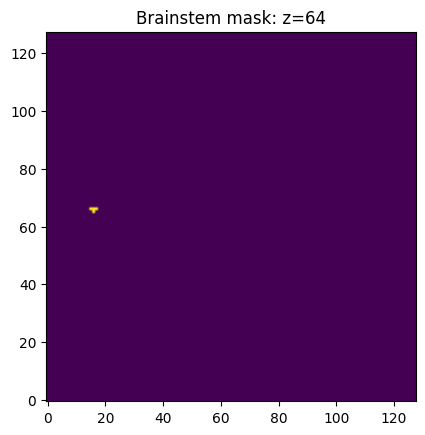

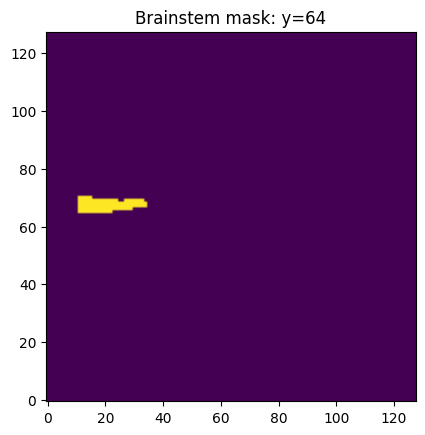

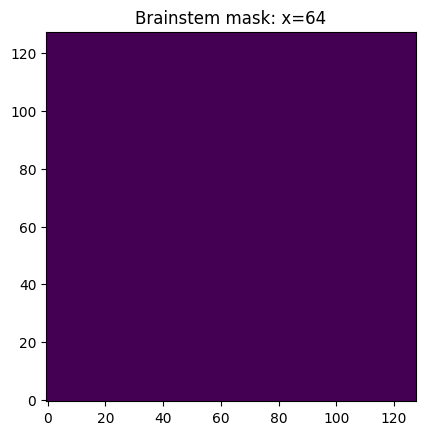

In [30]:
# ---- plot 3 orthogonal center slices ----
z = brainstem_mask.shape[0] // 2
y = brainstem_mask.shape[1] // 2
x = brainstem_mask.shape[2] // 2

plt.figure()
plt.imshow(brainstem_mask[z, :, :], origin="lower")
plt.title(f"Brainstem mask: z={z}")
plt.show()

plt.figure()
plt.imshow(brainstem_mask[:, y, :], origin="lower")
plt.title(f"Brainstem mask: y={y}")
plt.show()

plt.figure()
plt.imshow(brainstem_mask[:, :, x], origin="lower")
plt.title(f"Brainstem mask: x={x}")
plt.show()